In [19]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from xgboost import XGBRegressor 
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV , learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [20]:
train=pd.read_csv("train.csv")

In [21]:
test=pd.read_csv("test.csv")

In [22]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

<Axes: >

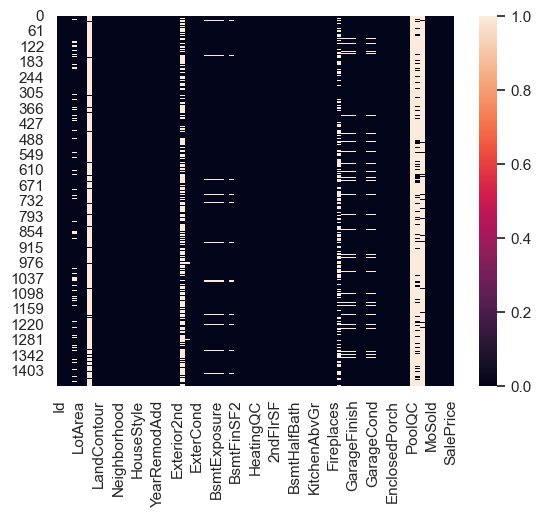

In [23]:
sns.heatmap(train.isnull())

In [24]:
# Filter and display only columns that have at least one NaN
nan_report = train.isnull().sum()[train.isnull().sum() > 0]

print("Columns with NaN values and their counts:")
print(nan_report)

Columns with NaN values and their counts:
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [25]:
train.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [26]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Skewness : 1.88
Kurtosis : 6.54


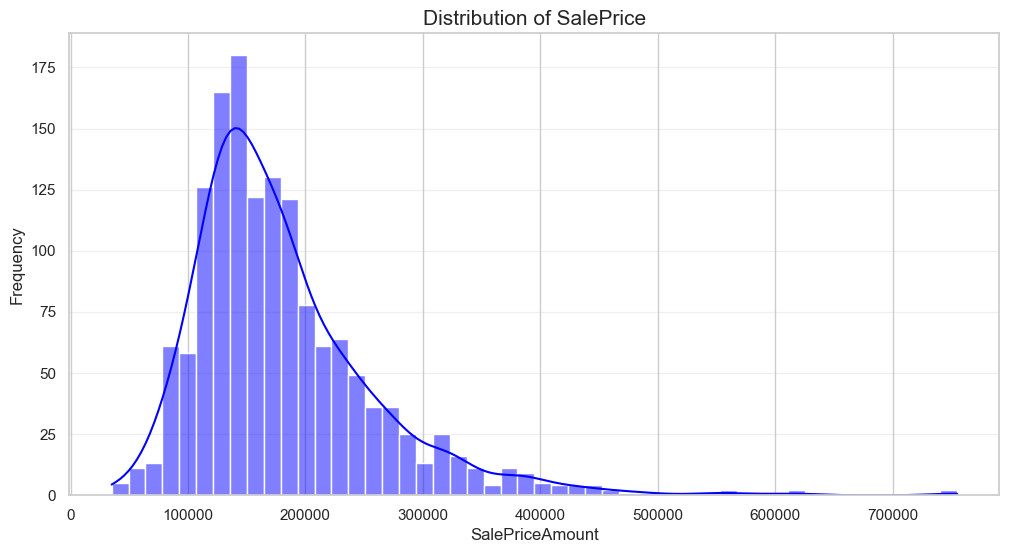

In [27]:

plt.figure(figsize=(12, 6))
sns.histplot(train['SalePrice'], kde=True, color='blue', bins=50)
plt.title('Distribution of SalePrice', fontsize=15)
plt.xlabel('SalePriceAmount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

print(f"Skewness : {train['SalePrice'].skew():.2f}")
print(f"Kurtosis : {train['SalePrice'].kurt():.2f}")

plt.show()

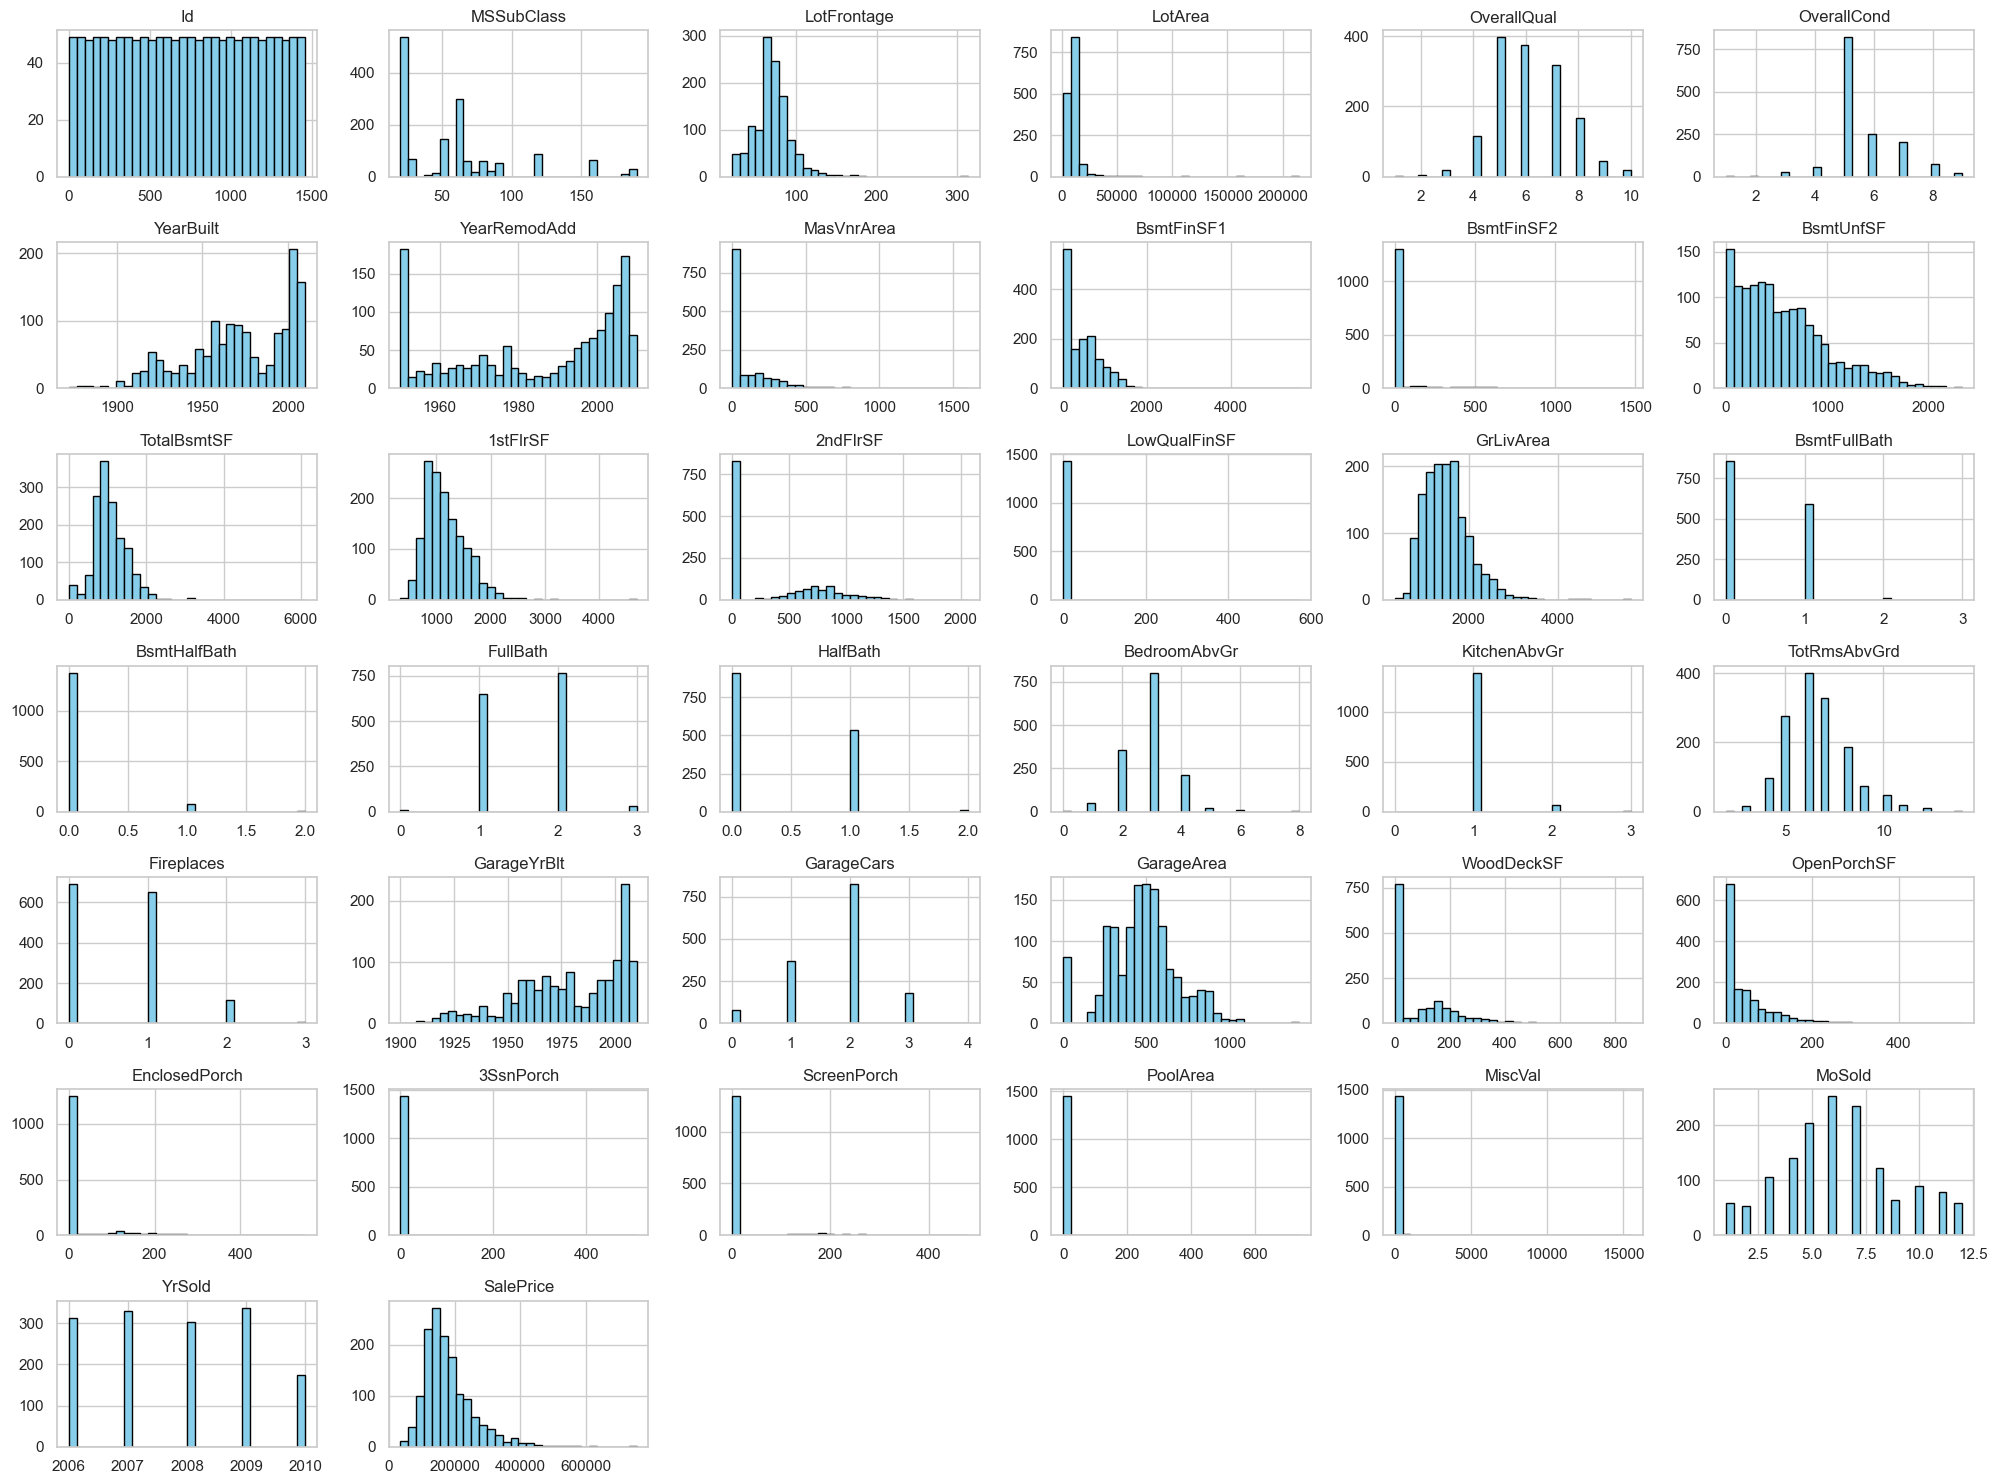

In [28]:

numeric_features = train.select_dtypes(include=['int64', 'float64']).columns
train[numeric_features].hist(bins=30, figsize=(20, 15), color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

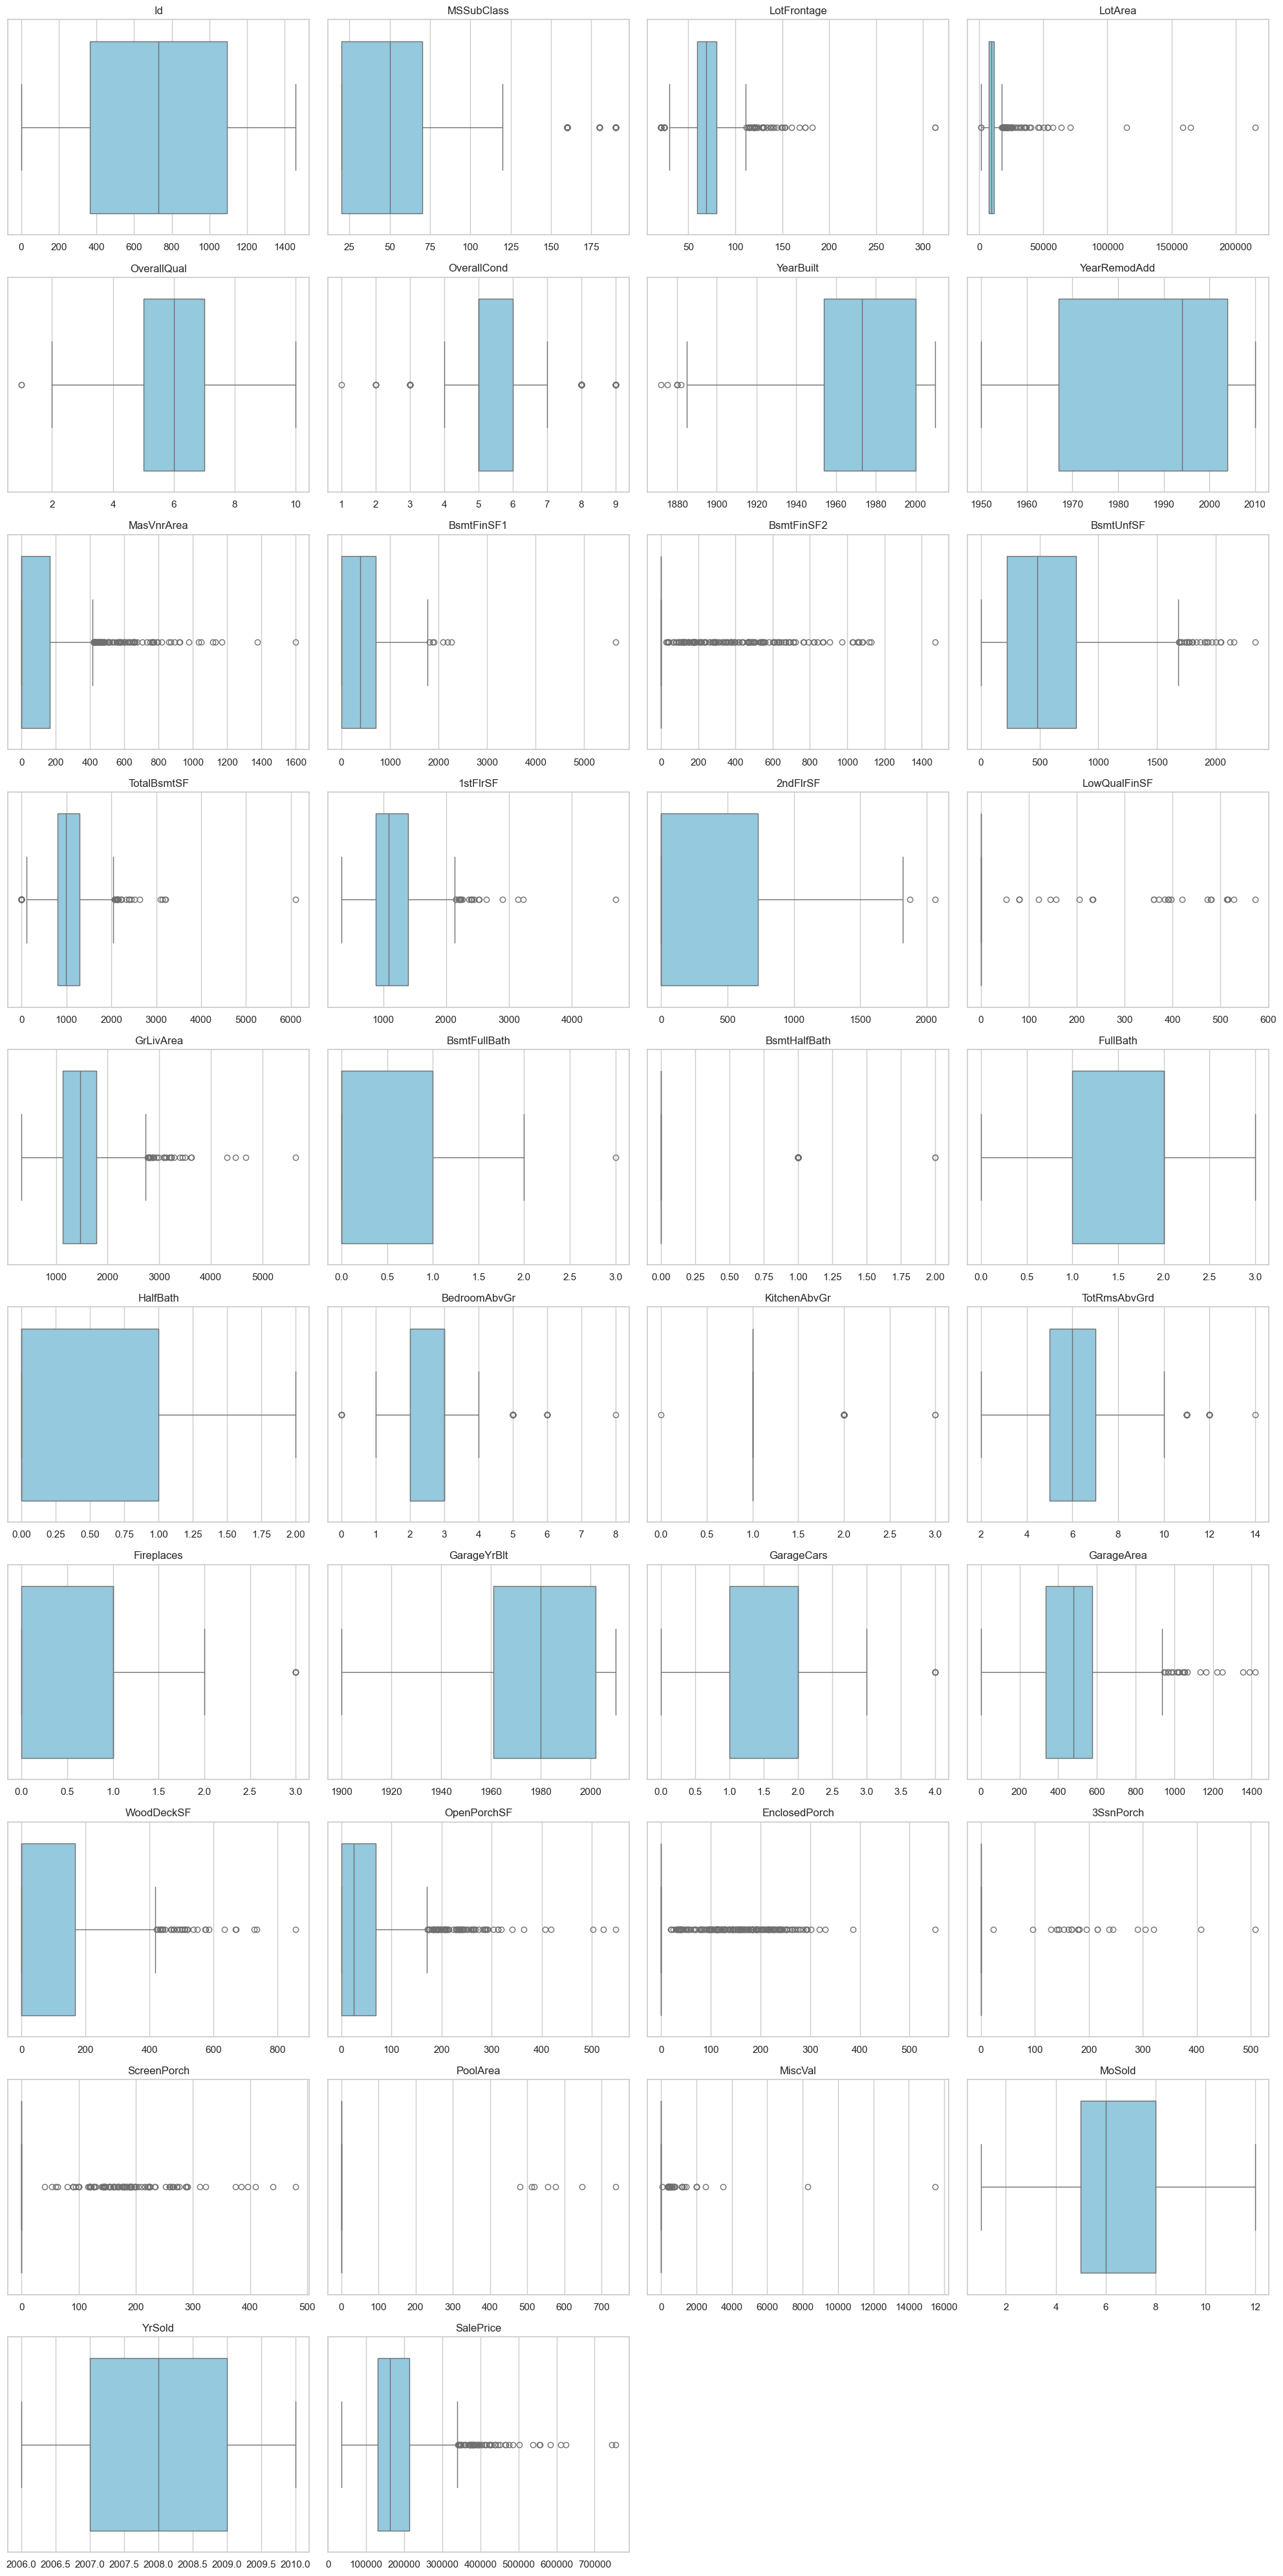

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = train.select_dtypes(include=['number'])

n_cols = 4
n_rows = (len(numeric_df.columns) // n_cols) + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_df.columns):
    sns.boxplot(data=train, x=col, ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

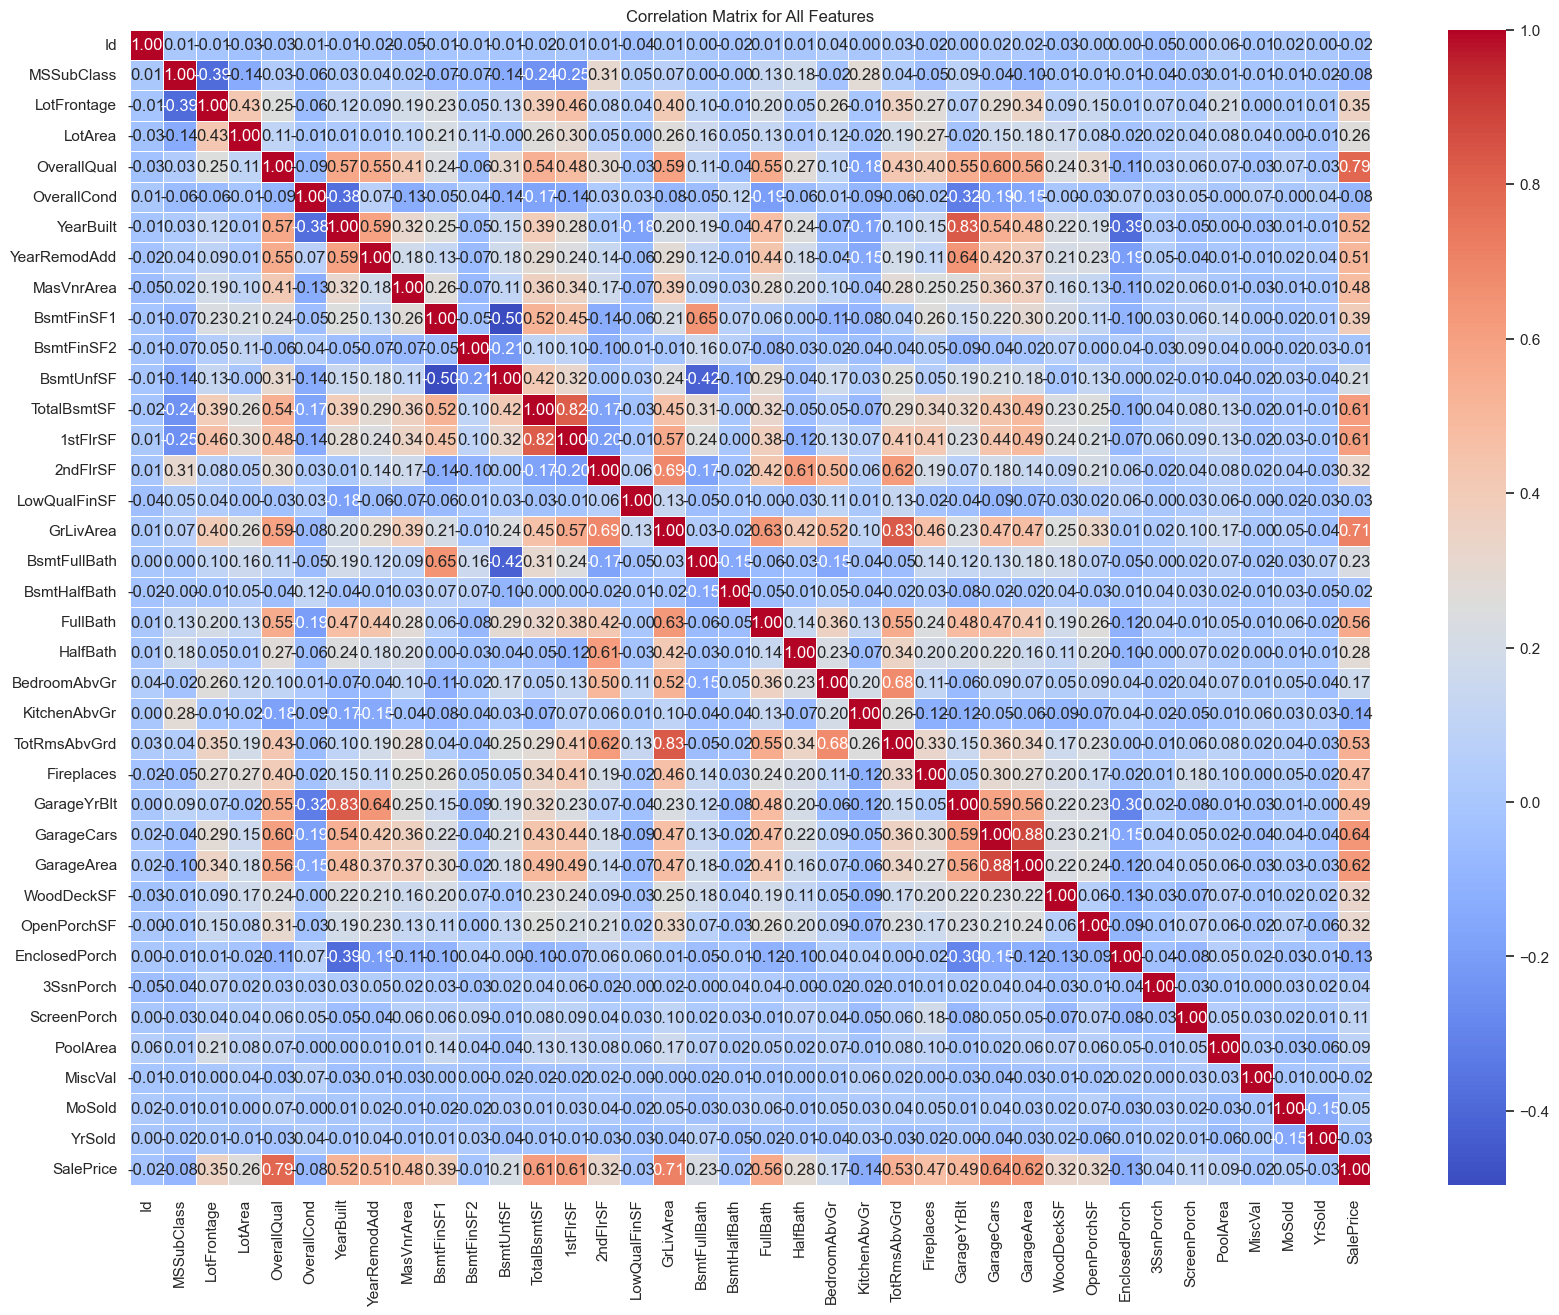

C:\Users\Compumarts\AppData\Local\Temp\ipykernel_23080\2060368130.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


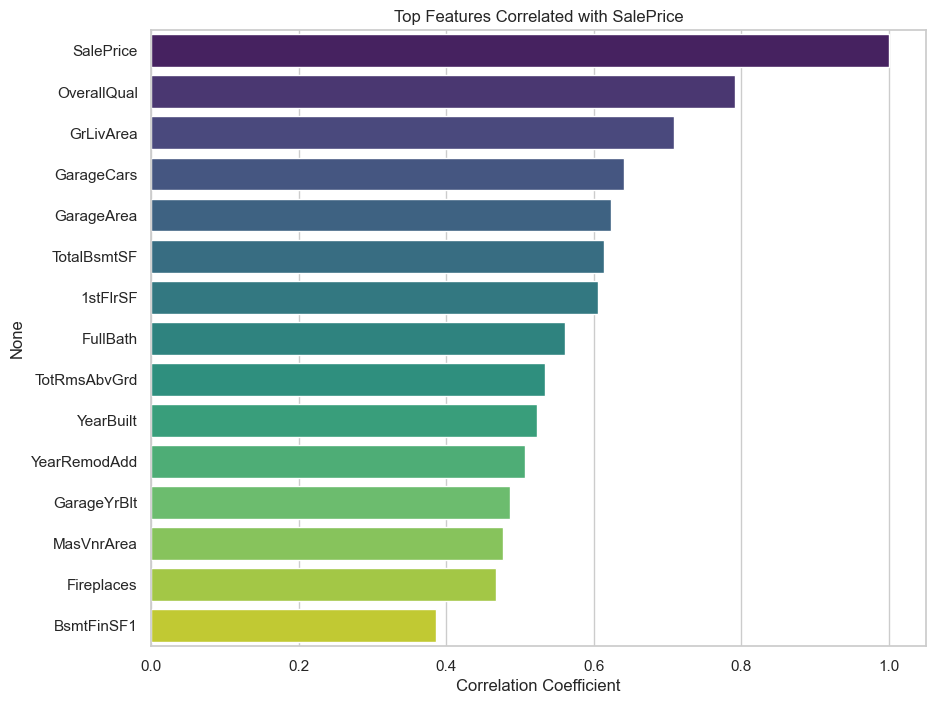

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = train.select_dtypes(include=['number']).corr()


plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix for All Features")
plt.show()
top_corr = corr_matrix['SalePrice'].sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')
plt.title("Top Features Correlated with SalePrice")
plt.xlabel("Correlation Coefficient")
plt.show()

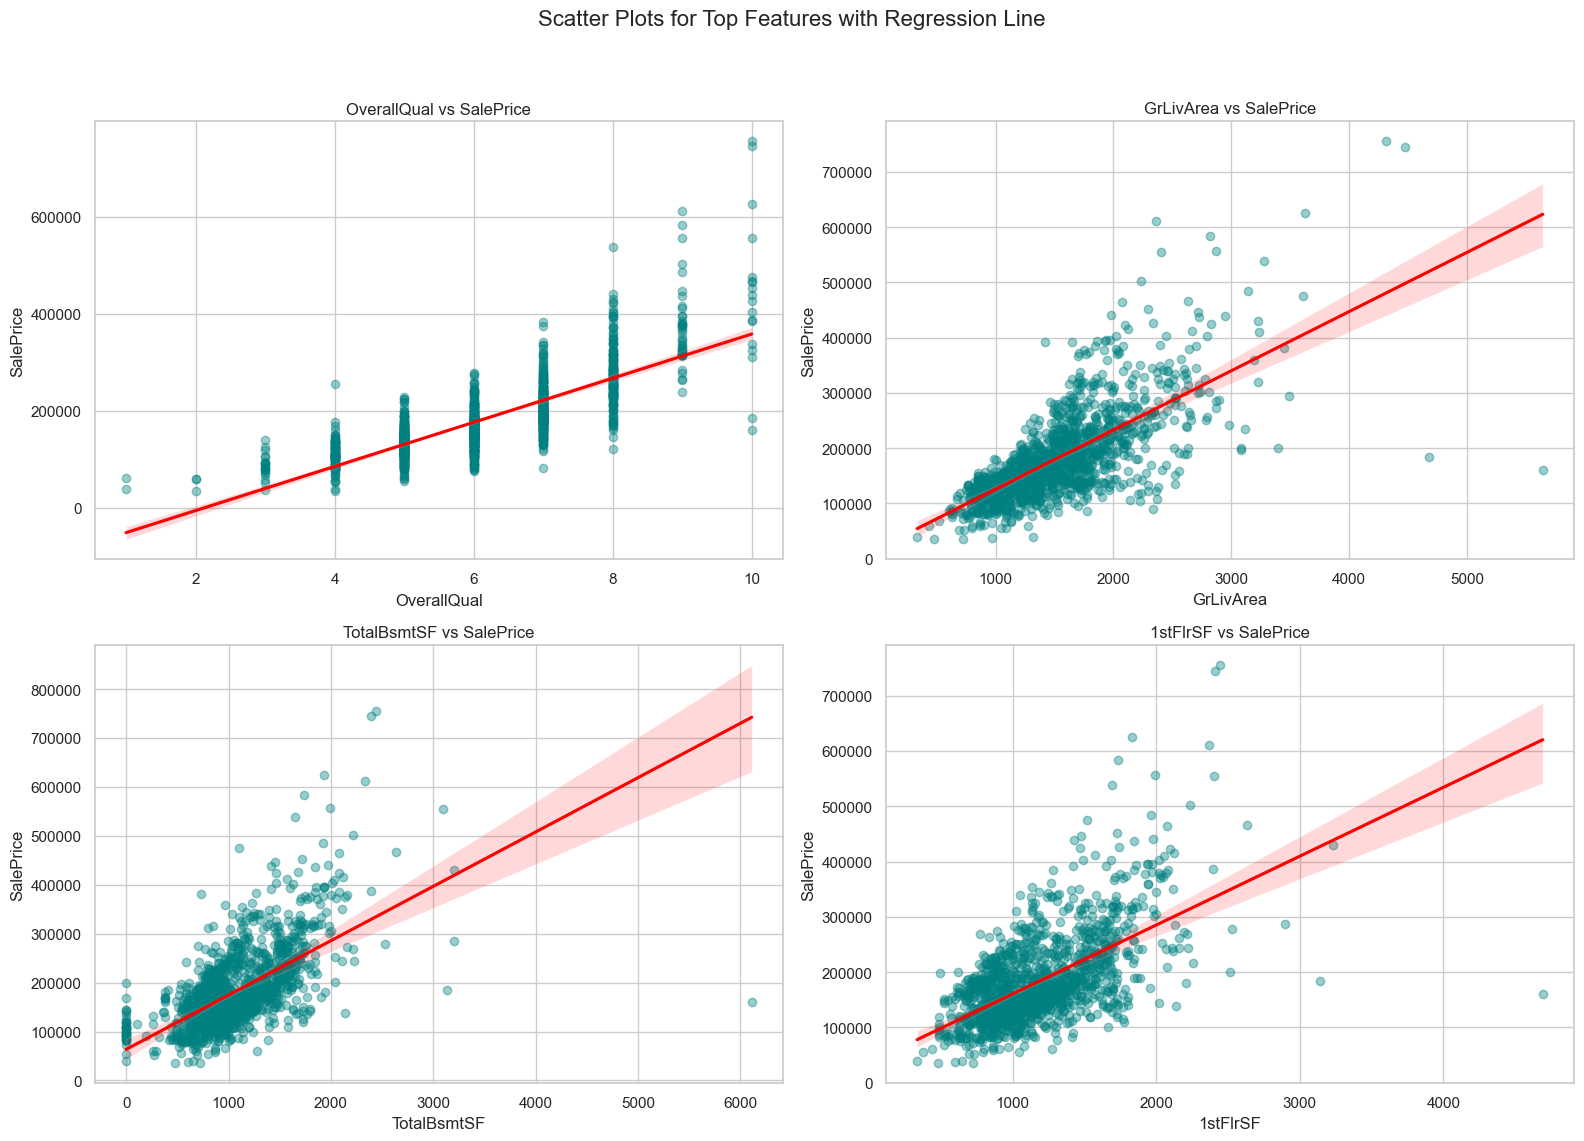

In [31]:

top_4_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Scatter Plots for Top Features with Regression Line', fontsize=16)

for i, col in enumerate(top_4_features):
    row, ax_idx = divmod(i, 2)
    sns.regplot(data=train, x=col, y='SalePrice', ax=axes[row, ax_idx], 
                scatter_kws={'alpha':0.4, 'color':'teal'}, 
                line_kws={'color':'red'})
    axes[row, ax_idx].set_title(f'{col} vs SalePrice')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [32]:

train = pd.read_csv('train.csv')
train = train.drop(train[(train['GrLivArea']>4000) & (train['SalePrice']<300000)].index)


def create_features(df):
    df_new = df.copy()
    

    df_new['TotalSF'] = df_new['TotalBsmtSF'] + df_new['1stFlrSF'] + df_new['2ndFlrSF']
    
  
    df_new['TotalBath'] = df_new['FullBath'] + (0.5 * df_new['HalfBath']) + df_new['BsmtFullBath'] + (0.5 * df_new['BsmtHalfBath'])
    

    df_new['HouseAge'] = df_new['YrSold'] - df_new['YearBuilt']
    

    df_new['IsRemodeled'] = (df_new['YearRemodAdd'] != df_new['YearBuilt']).astype(int)
    
    return df_new


train = create_features(train)
test = create_features(test)

X = train.drop(['Id', 'SalePrice'], axis=1)
y = np.log1p(train['SalePrice'])


cols_none = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "MasVnrType"]
cols_zero = ["GarageYrBlt", "GarageArea", "GarageCars", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath", "MasVnrArea"]
cols_mode = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType', 'Functional', 'Utilities']


num_cols = [col for col in X.select_dtypes(include=np.number).columns if col not in cols_zero]


pipe_none = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='None')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
pipe_zero = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value=0)), ('scaler', RobustScaler())])
pipe_mode = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
pipe_num = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())])

preprocessor = ColumnTransformer(
    transformers=[
        ('none_cats', pipe_none, cols_none),
        ('zero_nums', pipe_zero, cols_zero),
        ('mode_cats', pipe_mode, cols_mode),
        ('other_nums', pipe_num, num_cols)
    ], remainder='drop'
)


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor


mlflow.set_experiment("House_Price_Tree_Models")


def plot_learning_curve(estimator, title, X, y, filename, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='neg_root_mean_squared_error'
    )
    train_scores_mean = -np.mean(train_scores, axis=1)
    val_scores_mean = -np.mean(val_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.xlabel("Training Examples")
    plt.ylabel("RMSE")
    plt.grid()
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Error")
    plt.plot(train_sizes, val_scores_mean, 'o-', color="g", label="Validation Error")
    plt.legend(loc="best")
    plt.savefig(filename)
    plt.close()


print("🚀 Starting Unified Model Training Pipeline...")


with mlflow.start_run(run_name="Ultimate_Ensemble_Pipeline"):

    print("\n--- 1. Training LightGBM ---")
    with mlflow.start_run(run_name="LightGBM_Tuned", nested=True):
        pipeline_lgbm = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', LGBMRegressor(random_state=42, verbose=-1))
        ])

        param_grid_lgbm = {
            'model__n_estimators': [100, 200, 300],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__max_depth': [3, 4, 5],
            'model__num_leaves': [15, 31, 50]
        }

        search_lgbm = RandomizedSearchCV(pipeline_lgbm, param_grid_lgbm, n_iter=15, 
                                         scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1, random_state=42)
        search_lgbm.fit(X_train, y_train)
        best_lgbm = search_lgbm.best_estimator_
        
        y_pred_lgbm = best_lgbm.predict(X_val)
        mlflow.log_params(search_lgbm.best_params_)
        mlflow.log_metrics({
            "RMSE": np.sqrt(mean_squared_error(y_val, y_pred_lgbm)),
            "R2": r2_score(y_val, y_pred_lgbm)
        })
        mlflow.sklearn.log_model(best_lgbm, "lgbm_model")
        print(f"✅ LightGBM RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_lgbm)):.5f}")


    print("\n--- 2. Training XGBoost ---")
    with mlflow.start_run(run_name="XGBoost_Tuned", nested=True):
        pipeline_xgb = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', XGBRegressor(random_state=42, objective='reg:squarederror'))
        ])

        param_grid_xgb = {
            'model__n_estimators': [100, 200, 300],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__max_depth': [3, 4, 5],
            'model__min_child_weight': [1, 3, 5]
        }

        search_xgb = RandomizedSearchCV(pipeline_xgb, param_grid_xgb, n_iter=15, 
                                        scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1, random_state=42)
        search_xgb.fit(X_train, y_train)
        best_xgb = search_xgb.best_estimator_
        
        y_pred_xgb = best_xgb.predict(X_val)
        mlflow.log_params(search_xgb.best_params_)
        mlflow.log_metrics({
            "RMSE": np.sqrt(mean_squared_error(y_val, y_pred_xgb)),
            "R2": r2_score(y_val, y_pred_xgb)
        })
        mlflow.sklearn.log_model(best_xgb, "xgb_model")
        print(f"✅ XGBoost RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_xgb)):.5f}")


    print("Training Ensemble (LGBM + XGBoost)")
    with mlflow.start_run(run_name="Voting_Ensemble", nested=True):
        
        
        ensemble_model = VotingRegressor(
            estimators=[
                ('lightgbm', best_lgbm), 
                ('xgboost', best_xgb)
            ],
            weights=[0.5, 0.5]
        )
        
        ensemble_model.fit(X_train, y_train)
        y_pred_ensemble = ensemble_model.predict(X_val)
        

        rmse_ensemble = np.sqrt(mean_squared_error(y_val, y_pred_ensemble))
        r2_ensemble = r2_score(y_val, y_pred_ensemble)
        
        mlflow.log_metrics({"RMSE": rmse_ensemble, "R2": r2_ensemble})
        mlflow.sklearn.log_model(ensemble_model, "ensemble_model")
        
        print(f" Ensemble RMSE: {rmse_ensemble:.5f}")
        print(f" Ensemble R2: {r2_ensemble:.5f}")


        plot_learning_curve(ensemble_model, "Learning Curve - Final Ensemble", X_train, y_train, "ensemble_learning_curve.png")
        mlflow.log_artifact("ensemble_learning_curve.png")
        

        plt.figure(figsize=(8, 6))
        plt.scatter(y_val, y_pred_ensemble, alpha=0.5, color='crimson', edgecolor='k')
        plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--', lw=2) 
        plt.title('Ensemble: Actual vs Predicted', fontsize=14, fontweight='bold')
        plt.xlabel('Actual SalePrice (Log)', fontsize=12)
        plt.ylabel('Predicted SalePrice (Log)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.savefig("ensemble_actual_vs_predicted.png")
        mlflow.log_artifact("ensemble_actual_vs_predicted.png")
        plt.close()

print(" All models trained and logged successfully to MLflow!")

🚀 Starting Unified Model Training Pipeline...

--- 1. Training LightGBM ---


c:\Users\Compumarts\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
2026/04/12 16:07:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ LightGBM RMSE: 0.12992

--- 2. Training XGBoost ---


2026/04/12 16:07:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ XGBoost RMSE: 0.12158

--- 3. Training Ensemble (LGBM + XGBoost) ---


c:\Users\Compumarts\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
2026/04/12 16:07:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏆 Ensemble RMSE: 0.12491
🏆 Ensemble R2: 0.90744

🎉 All models trained and logged successfully to MLflow!
